In [19]:
import pandas as pd
import japanize_matplotlib
from matplotlib import pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import to_rgba
import numpy as np

### 避難率データの推移

### CSVデータ取り込み

In [ ]:
# 読み込むデータの条件
FOLDERID = "Yokosuka_AgentsModel_e4a30974-8b14-4197-b529-bcd4cc2bb57d"
AREA = "Yokosuka"
AGENTS_MODE = True
EPSODERANGE = (0, 10)

# 読み込むデータのパス
modeName = "AgentsModel" if AGENTS_MODE else "EvacueesOnly"
dfs: list[pd.DataFrame] = []
for episode in range(EPSODERANGE[0], EPSODERANGE[1]+1):
    filePath = f"../../Master-Simulator/Assets/Datas/{FOLDERID}/{AREA}_{modeName}_Ep-{episode}_evacuationRate.csv"

    df = pd.read_csv(filePath, header=0)
    # column名から余分なスペースを削除
    df.columns = df.columns.str.replace(" ", "")
    # 読み込みのデータフレームをリストに追加
    dfs.append(df)
    print(f"{filePath} is loaded.")

dfs[0].head(2)

../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-0_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-1_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-2_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-3_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-4_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-5_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-6_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-7_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-8_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-9_evacuationRate.csv is loaded.
../../Master-Simulator/Assets/Datas/Yokosuka_AgentsModel_Ep-10_evacuationRate.cs

,EvacuationRate,Time
0,0.0,0
1,0.0,1


### エピソード毎の避難率をプロット

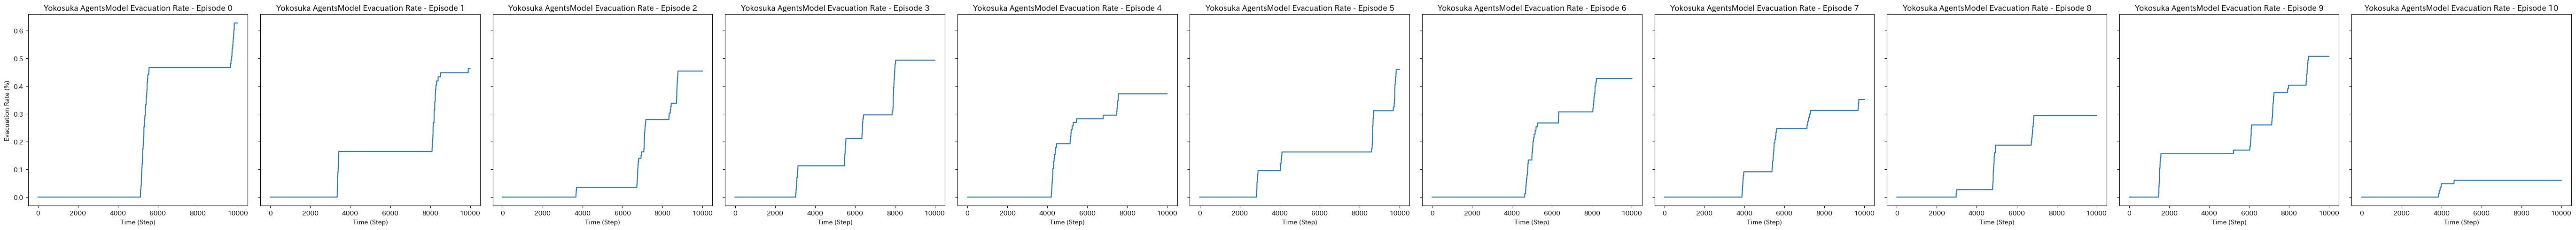

In [21]:
num_episodes = EPSODERANGE[1] - EPSODERANGE[0] + 1
fig, axes = plt.subplots(1, num_episodes, figsize=(5 * num_episodes, 5), sharey=True)

for i, episode in enumerate(range(EPSODERANGE[0], EPSODERANGE[1] + 1)):
    df = dfs[episode]
    ax = axes[i]
    ax.plot(df["Time"], df["EvacuationRate"], label=f"Episode {episode}")
    ax.set_title(f"{AREA} {modeName} Evacuation Rate - Episode {episode}")
    ax.set_xlabel("Time (Step)")
    ax.set_ylabel("Evacuation Rate (%)" if i == 0 else "")  # Y軸ラベルは最初のプロットのみ表示
    
plt.tight_layout()
plt.show()

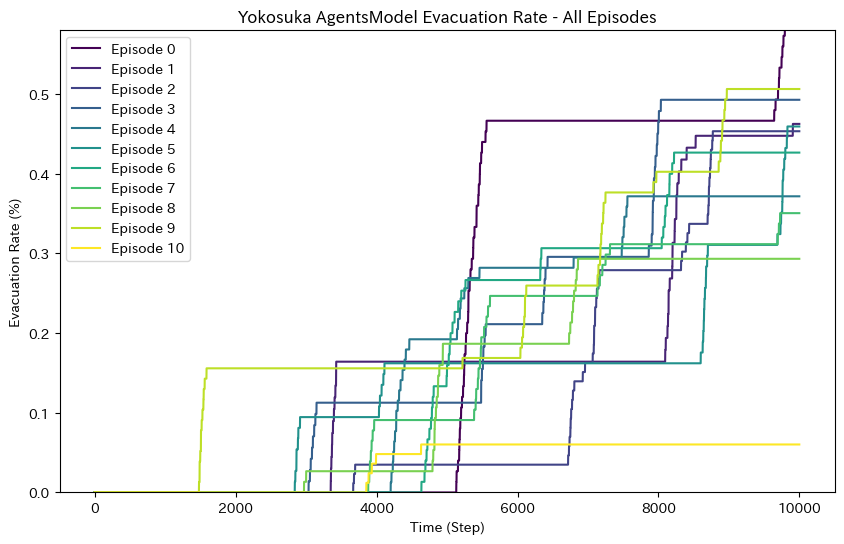

In [26]:
# カラーマップを使ってエピソードごとに色を自動的に割り当て
colors = cm.viridis(np.linspace(0, 1, EPSODERANGE[1] - EPSODERANGE[0] + 1))

plt.figure(figsize=(10, 6))

for i, episode in enumerate(range(EPSODERANGE[0], EPSODERANGE[1] + 1)):
    df = dfs[episode]
    plt.plot(df["Time"], df["EvacuationRate"], color=colors[i], label=f"Episode {episode}")

plt.ylim(0, 0.58)
plt.title(f"{AREA} {modeName} Evacuation Rate - All Episodes")
plt.xlabel("Time (Step)")
plt.ylabel("Evacuation Rate (%)")
plt.legend()
plt.show()